In [1]:
import matplotlib.pyplot as plt
%cd ..
import os
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"
%load_ext autoreload
%autoreload 2

/home/jafar/Arts/Parallel-Dynamic-Sparse-Training


/home/jafar/Arts/Parallel-Dynamic-Sparse-Training/venv/lib/python3.12/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [21]:
import json
import glob
import pandas as pd 
import numpy as np

from benchmark.plots.matrix_matrix import *

dense_level = "5200x5200"
df = pd.DataFrame()
for sparse_type in [
        "test_sparse_cupy",
        "test_sparse_cupy_csr",
        "test_sparse_torch_csr",
        "test_jax_bsr",
        "test_sparse_ut",
        "test_sparse_torch", 
        "test_dense",
]:
    
    dfc = pd.read_csv(f"/home/jafar/Arts/Parallel-Dynamic-Sparse-Training/benchmark/log_mult_incl_cupy-{sparse_type}.csv")

    
    dfc["Type"] = dfc["isSparse"].apply(lambda x: sparse_type.replace("test_",""))
    
    dfc["sparsity_level"] = dfc["sparsity_level"] * 100 / (dfc["sparsity_level"].max())
    df = pd.concat([df, dfc])
    # display(df.tail())
    if dense_level not in df['dense_level'].tolist():
        raise RuntimeError("Dense level is not in df")
    
print(df.Type.unique())

['sparse_cupy' 'sparse_cupy_csr' 'sparse_torch_csr' 'jax_bsr' 'sparse_ut'
 'sparse_torch' 'dense']


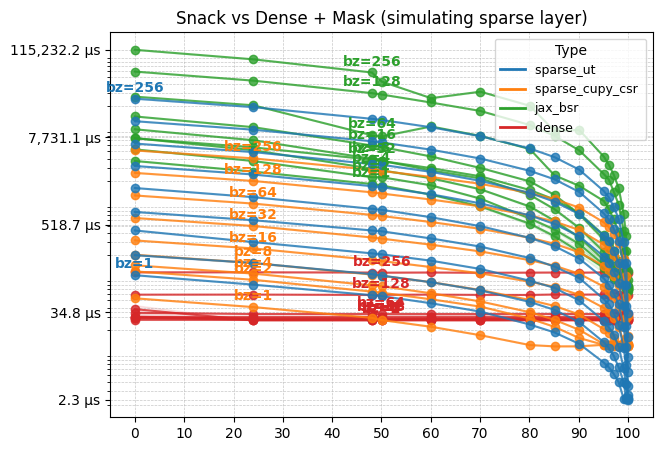

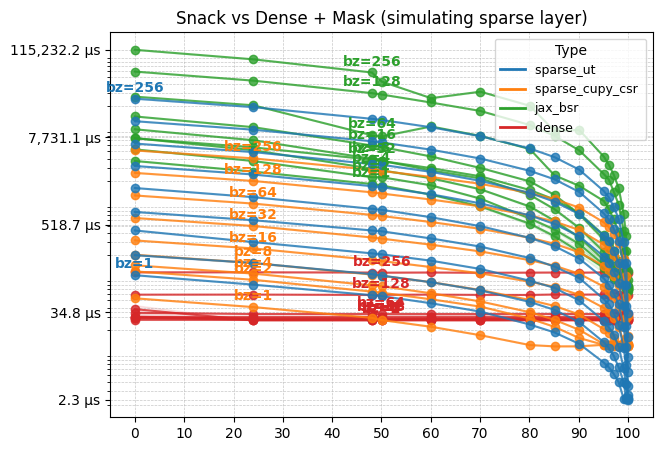

In [35]:
dfc = df[df.sparsity_level >= 0]
create_single_plot_for_batches(
    dfc, 
    dense_level, 
    "cuda_elapsed_time",
    [1 << i for i in range(10)],
    figsize=(7, 5), 
    log=True,
    title="Snack vs Dense + Mask (simulating sparse layer)",
    batch_needed=True,
    categories=[
        # "sparse_cupy",
        "sparse_ut",
        "sparse_cupy_csr",
        # "sparse_torch_csr",
        "jax_bsr",
        
        # "sparse_torch",
        "dense"
    ]
)


(24, 7)


,isSparse,batch_size,dense_level,cuda_elapsed_time,total_params,sparsity_level,rep
0,Sparse,1,10000x10000,443.662323,100000000,0.000000,0
1,Dense,1,10000x10000,1146.226685,100010000,0.000000,0
18,Sparse,1,10000x10000,356.305908,80000000,20.202020,0
19,Dense,1,10000x10000,1081.587769,100010000,20.202020,0
36,Sparse,1,10000x10000,271.612915,60000000,40.404040,0
37,Dense,1,10000x10000,1081.448486,100010000,40.404040,0
54,Sparse,1,10000x10000,226.748413,50000000,50.505051,0
55,Dense,1,10000x10000,1081.110474,100010000,50.505051,0
72,Sparse,1,10000x10000,181.601273,40000000,60.606061,0
73,Dense,1,10000x10000,1080.634399,100010000,60.606061,0


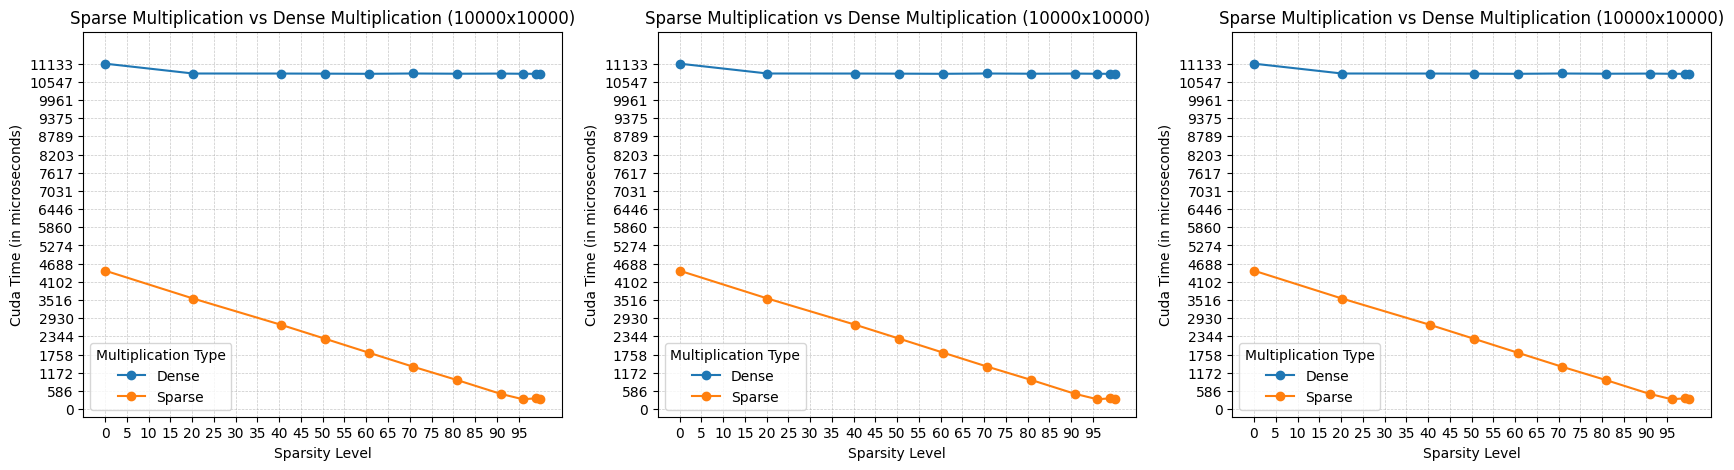

In [4]:

fig, ax = plt.subplots(1,3,figsize=(21, 5));
bz = 1
df_dlvl = df[(df.dense_level == dense_level) & (df.batch_size == bz)]
print(df_dlvl.shape)
plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)

def plt_them(df_dlvl, ax=None):

    
    max_min_avg_s = 0
    
        
    for category, group in df_dlvl.groupby('isSparse'):
        avg_per_sparsity = group.groupby('sparsity_level')['cuda_elapsed_time'].mean() * 10
        std_per_sparsity = group.groupby('sparsity_level')['cuda_elapsed_time'].std() * 10
        sparsity_level = group.groupby('sparsity_level')['sparsity_level'].first()
        max_min_avg_s = max(max_min_avg_s, avg_per_sparsity.max())
        
        ax.plot(sparsity_level, avg_per_sparsity, marker='o', linestyle='-', label=category)
        ax.fill_between(sparsity_level, avg_per_sparsity - std_per_sparsity, avg_per_sparsity + std_per_sparsity, alpha=0.2)

    ax.set_xticks(list(range(int(df_dlvl.sparsity_level.min()), 100, 5)))
    ax.set_yticks(np.linspace(0, max_min_avg_s, 20))
    
    ax.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
    
    ax.set_title(f'Sparse Multiplication vs Dense Multiplication ({dense_level})')
    ax.set_xlabel('Sparsity Level')
    ax.set_ylabel('Cuda Time (in microseconds)')
    
    ax.legend(title='Multiplication Type')

    
    #return fig, ax  # Return figure and axis
plt_them(df_dlvl, ax=ax[0])

df_dlvl = df_dlvl[df_dlvl.dense_level == dense_level] 

plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)

# Group by the 'category' column and plot each group
df_dlvl=df_dlvl[df_dlvl.isSparse != 'SparseTorch']
plt_them(df_dlvl, ax=ax[1])



plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)

# Group by the 'category' column and plot each group
df_dlvl=df_dlvl[~df_dlvl.isSparse.isin(['SparseTorch', 'JaxSparse'])]
plt_them(df_dlvl, ax[2])
display(df_dlvl)